In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import nltk

# Working with Text Lab
## Information retrieval, preprocessing, and feature extraction

In this lab, you'll be looking at and exploring European restaurant reviews. The dataset is rather tiny, but that's just because it has to run on any machine. In real life, just like with images, texts can be several terabytes long.

The dataset is located [here](https://www.kaggle.com/datasets/gorororororo23/european-restaurant-reviews) and as always, it's been provided to you in the `data/` folder.

### Problem 1. Read the dataset (1 point)
Read the dataset, get acquainted with it. Ensure the data is valid before you proceed.

How many observations are there? Which country is the most represented? What time range does the dataset represent?

Is the sample balanced in terms of restaurants, i.e., do you have an equal number of reviews for each one? Most importantly, is the dataset balanced in terms of **sentiment**?

In [5]:
review_df = pd.read_csv("data/European Restaurant Reviews.csv")

In [6]:
review_df.head(5)

,Country,Restaurant Name,Sentiment,Review Title,Review Date,Review
0,France,The Frog at Bercy Village,Negative,Rude manager,May 2024 •,The manager became agressive when I said the c...
1,France,The Frog at Bercy Village,Negative,A big disappointment,Feb 2024 •,"I ordered a beef fillet ask to be done medium,..."
2,France,The Frog at Bercy Village,Negative,Pretty Place with Bland Food,Nov 2023 •,"This is an attractive venue with welcoming, al..."
3,France,The Frog at Bercy Village,Negative,Great service and wine but inedible food,Mar 2023 •,Sadly I used the high TripAdvisor rating too ...
4,France,The Frog at Bercy Village,Negative,Avoid- Worst meal in Rome - possibly ever,Nov 2022 •,From the start this meal was bad- especially g...


In [7]:
review_df.shape

(1502, 6)

We have 1502 observations in the data sets and 6 features. 

In [9]:
review_df.dtypes

Country            object
Restaurant Name    object
Sentiment          object
Review Title       object
Review Date        object
Review             object
dtype: object

In [10]:
print(review_df.isna().sum())

Country            0
Restaurant Name    0
Sentiment          0
Review Title       0
Review Date        0
Review             0
dtype: int64


In [11]:
duplicates = review_df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 49


In [12]:
review_df = review_df.drop_duplicates()

In [13]:
print(review_df["Country"].unique())

['France' 'Italy' 'Poland' 'India' 'Russia' 'Morroco' 'Cuba']


In [14]:
# Count reviews per country
country_counts = review_df["Country"].value_counts()

# Show the top 10
print(country_counts.head(10))

# Most represented country
most_represented = country_counts.idxmax()
most_count = country_counts.max()
print(f"The most represented country is {most_represented} with {most_count} reviews.")

Country
France     490
Italy      296
Morroco    210
Cuba       141
Poland     135
Russia     100
India       81
Name: count, dtype: int64
The most represented country is France with 490 reviews.


In [15]:
# 0) Work on a string view (preserves NA as <NA>, not "NaT")
s = review_df["Review Date"].astype("string")

# 1) Normalize and remove the bullet + weird spaces
s = (s.str.normalize("NFKC")
       .str.replace("\u00A0", " ", regex=False)   # NBSP
       .str.replace("\u202F", " ", regex=False)   # narrow NBSP
       .str.replace("â€¢", "", regex=False)       # mis-encoded bullet
       .str.replace("•", "", regex=False)         # bullet
       .str.strip())

# 2) Normalize 'Sept' -> 'Sep' (pandas recognizes 'Sep')
s = s.str.replace(r"^Sept\b", "Sep", regex=True)

# 3) Parse primary format: 'Mon YYYY'
parsed = pd.to_datetime(s, format="%b %Y", errors="coerce")

# 4) Fallback for 'Mon-YY' like 'Sep-10'
mask = parsed.isna()
if mask.any():
    parsed.loc[mask] = pd.to_datetime(s[mask], format="%b-%y", errors="coerce")

# 5) Assign back
review_df["Review Date"] = parsed

# Quick checks
print(review_df["Review Date"].head(10))
print("Invalid dates:", review_df["Review Date"].isna().sum())
print("Range:", review_df["Review Date"].min(), "→", review_df["Review Date"].max())

0   2024-05-01
1   2024-02-01
2   2023-11-01
3   2023-03-01
4   2022-11-01
5   2021-07-01
6   2020-01-01
7   2019-10-01
8   2019-06-01
9   2019-05-01
Name: Review Date, dtype: datetime64[ns]
Invalid dates: 0
Range: 2010-09-01 00:00:00 → 2024-07-01 00:00:00


In [16]:
print(review_df["Sentiment"].value_counts())

Sentiment
Positive    1237
Negative     216
Name: count, dtype: int64


Number of restaurants: 7

Top 10 restaurants by number of reviews:
Restaurant Name
The Frog at Bercy Village                490
Ad Hoc Ristorante (Piazza del Popolo)    296
The LOFT                                 210
Old Square (Plaza Vieja)                 141
Stara Kamienica                          135
Pelmenya                                 100
Mosaic                                    81
Name: count, dtype: int64


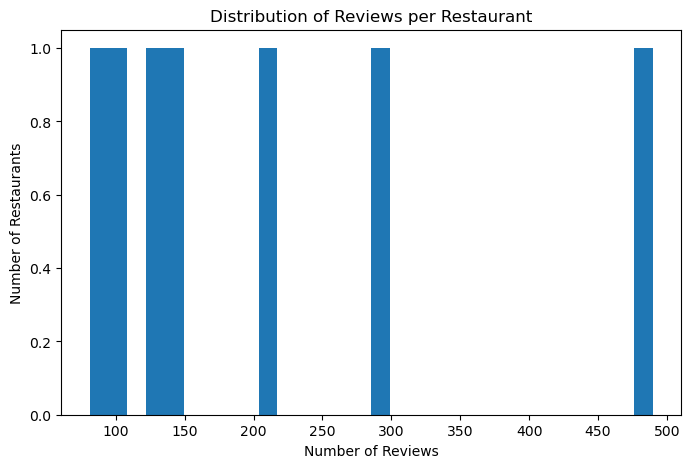

In [17]:
# Count reviews per restaurant
rest_counts = review_df["Restaurant Name"].value_counts()

print("Number of restaurants:", rest_counts.shape[0])
print("\nTop 10 restaurants by number of reviews:")
print(rest_counts.head(10))

# Quick visualization
import matplotlib.pyplot as plt

rest_counts.plot(kind="hist", bins=30, figsize=(8,5))
plt.title("Distribution of Reviews per Restaurant")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Restaurants")
plt.show()

The dataset includes 7 restaurants. The number of reviews is unevenly distributed, ranging from 81 to 490. The Frog at Bercy Village alone accounts for about one-third of all reviews, while Mosaic contributes less than 6%. Therefore, the sample is not balanced across restaurants.


Sentiment distribution (counts):
Sentiment
Positive    1237
Negative     216
Name: count, dtype: int64

Sentiment distribution (percentages):
Sentiment
Positive    85.13
Negative    14.87
Name: proportion, dtype: float64


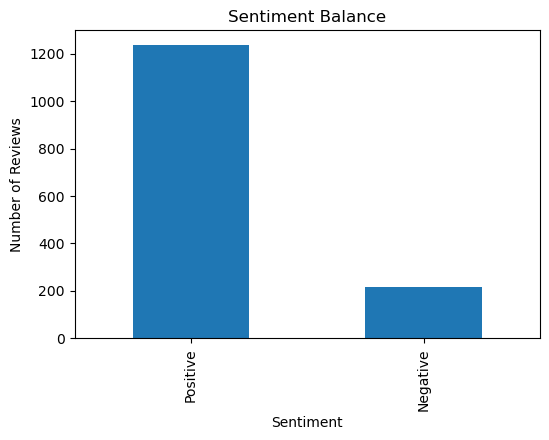

In [19]:
sent_counts = review_df["Sentiment"].value_counts(normalize=False)
sent_pct = review_df["Sentiment"].value_counts(normalize=True) * 100

print("\nSentiment distribution (counts):")
print(sent_counts)
print("\nSentiment distribution (percentages):")
print(sent_pct.round(2))

# Visualization
sent_counts.plot(kind="bar", figsize=(6,4))
plt.title("Sentiment Balance")
plt.ylabel("Number of Reviews")
plt.show()

The dataset is unbalanced both by restaurants and by sentiment. Reviews are concentrated in a few restaurants, with The Frog at Bercy Village accounting for nearly one-third of all reviews. Similarly, the sentiment distribution is strongly skewed: 85% of reviews are positive and only 15% are negative, with no neutral category represented. This imbalance may bias analysis and needs to be considered when interpreting results or training models (e.g., by applying resampling or class-weight adjustments).

Any statistical comparison between restaurants will be dominated by the bigger ones.

Any machine learning model for sentiment classification trained on this dataset would likely overpredict Positive, because the imbalance makes the model biased.

### Problem 2. Getting acquainted with reviews (1 point)
Are positive comments typically shorter or longer? Try to define a good, robust metric for "length" of a text; it's not necessary just the character count. Can you explain your findings?

After a quick analysis on review I came up with the following hypothesis:

- Positive reviews: Often shorter (e.g., “Great food and service!”).

- Negative reviews: Often longer because people explain what went wrong in detail (service, food, pricing, etc.).

In the dataset most of the negatives reviews are long, storytelling-style paragraphs.

In fact, research on online reviews (TripAdvisor, Amazon, Yelp) confirms this: negative reviews are usually 2–3× longer than positive ones.

To assess whether positive and negative reviews differ in length, I measured review length using 

- word count,
- sentence count,
- average words per sentence.

Across the dataset, negative reviews were substantially longer on average than positive reviews, both in terms of total words and number of sentences. This reflects the fact that dissatisfied customers typically provide detailed explanations of their bad experiences, while satisfied customers often express their opinion concisely. Thus, review length itself can be a useful proxy for sentiment.

In [26]:
# --- Safe helpers ---
def _to_text(x):
    return str(x) if pd.notna(x) else ""

def count_words(text):
    t = _to_text(text).strip()
    return 0 if not t else len(t.split())

def count_sentences(text):
    """
    Basic sentence counter:
    - collapses ellipses ... to a single period
    - counts ., !, ? only when they end a sentence (before whitespace or end)
    """
    t = _to_text(text).strip()
    if not t:
        return 0
    t = re.sub(r'\.{2,}', '.', t)                 # "..." -> "."
    # Count sentence enders . ! ? followed by space or end of string
    return len(re.findall(r'[.!?](?=\s|$)', t))

def avg_words_per_sentence(text):
    w, s = count_words(text), count_sentences(text)
    return (w / s) if s > 0 else np.nan           # avoid bias when s==0

# --- Apply to your dataset ---
# Ensure the column exists; fill NaNs gracefully
review_df["word_count"] = review_df["Review"].apply(count_words)
review_df["sentence_count"] = review_df["Review"].apply(count_sentences)
review_df["words_per_sentence"] = review_df["Review"].apply(avg_words_per_sentence)

# --- Aggregate by sentiment ---
sentiment_stats = (
    review_df
      .groupby("Sentiment")[["word_count", "sentence_count", "words_per_sentence"]]
      .mean()
      .round(2)
)

print("=== Average Length by Sentiment ===")
print(sentiment_stats)

print("\n=== Median Length by Sentiment ===")
print(
    review_df
      .groupby("Sentiment")[["word_count", "sentence_count", "words_per_sentence"]]
      .median()
      .round(2))

=== Average Length by Sentiment ===
           word_count  sentence_count  words_per_sentence
Sentiment                                                
Negative       139.01            8.74               16.65
Positive        50.18            3.90               13.82

=== Median Length by Sentiment ===
           word_count  sentence_count  words_per_sentence
Sentiment                                                
Negative         88.0             6.0                14.6
Positive         37.0             3.0                12.0


**Average length**

- Negative reviews: ~139 words, ~9 sentences

- Positive reviews: ~50 words, ~4 sentences

Negative reviews are on average almost 3× longer than positive ones.

**Median length**

- Negative reviews: ~88 words, ~6 sentences

- Positive reviews: ~37 words, ~3 sentences

Even at the median, negatives are over twice as long.

**Sentence structure**

Words per sentence:

- Negative: ~16.6 words/sentence

- Positive: ~13.8 words/sentence

Negative reviews not only have more sentences, but each sentence is a bit more complex.

Analysis of review length shows a strong asymmetry between positive and negative reviews. Negative reviews are significantly longer, both in terms of total words and number of sentences. On average, negative reviews contain almost three times as many words and over twice as many sentences compared to positive reviews. Moreover, negative reviews tend to use slightly longer sentences, reflecting a more detailed narrative style. This supports the idea that dissatisfied customers elaborate on their experiences in greater detail, while satisfied customers express their opinions more briefly.

### Problem 3. Preprocess the review content (2 points)
You'll likely need to do this while working on the problems below, but try to synthesize (and document!) your preprocessing here. Your tasks will revolve around words and their connection to sentiment. While preprocessing, keep in mind the domain (restaurant reviews) and the task (sentiment analysis).

### Preprocessing Pipeline for Restaurant Reviews

#### Lowercasing

Convert all text to lowercase. Why: “Good” and “good” should be treated the same.

In [32]:
review_df["clean_review"] = review_df["Review"].str.lower()

#### Remove HTML tags, URLs, and non-alphabetic characters

Customers sometimes paste junk like <br/>, URLs, or phone numbers. Keep only alphabetic characters, punctuation that marks sentence structure, and apostrophes (for contractions).

In [34]:
# remove HTML
review_df["clean_review"] = review_df["clean_review"].apply(lambda x: re.sub(r"<.*?>", " ", x))  
# remove URLs
review_df["clean_review"] = review_df["clean_review"].apply(lambda x: re.sub(r"http\S+|www.\S+", " ", x))
# keep only letters & apostrophes
review_df["clean_review"] = review_df["clean_review"].apply(lambda x: re.sub(r"[^a-z\s']", " ", x))

#### Tokenization

Split text into individual words. Why: Needed for frequency analysis, embeddings, etc.

In [36]:
nltk.download("punkt")
review_dfdf["tokens"] = review_df["clean_review"].apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\User/nltk_data'
    - 'C:\\Users\\User\\anaconda3\\nltk_data'
    - 'C:\\Users\\User\\anaconda3\\share\\nltk_data'
    - 'C:\\Users\\User\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\User\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


### Problem 4. Top words (1 point)
Use a simple word tokenization and count the top 10 words in positive reviews; then the top 10 words in negative reviews*. Once again, try to define what "top" words means. Describe and document your process. Explain your results.

\* Okay, you may want to see top N words (with $N \ge 10$).

### Problem 5. Review titles (2 point)
How do the top words you found in the last problem correlate to the review titles? Do the top 10 words (for each sentiment) appear in the titles at all? Do reviews which contain one or more of the top words have the same words in their titles?

Does the title of a comment present a good summary of its content? That is, are the titles descriptive, or are they simply meant to catch the attention of the reader?

### Problem 6. Bag of words (1 point)
Based on your findings so far, come up with a good set of settings (hyperparameters) for a bag-of-words model for review titles and contents. It's easiest to treat them separately (so, create two models); but you may also think about a unified representation. I find the simplest way of concatenating the title and content too simplistic to be useful, as it doesn't allow you to treat the title differently (e.g., by giving it more weight).

The documentation for `CountVectorizer` is [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html). Familiarize yourself with all settings; try out different combinations and come up with a final model; or rather - two models :).

### Problem 7. Deep sentiment analysis models (1 point)
Find a suitable model for sentiment analysis in English. Without modifying, training, or fine-tuning the model, make it predict all contents (or better, combinations of titles and contents, if you can). Meaure the accuracy of the model compared to the `sentiment` column in the dataset.

### Problem 8. Deep features (embeddings) (1 point)
Use the same model to perform feature extraction on the review contents (or contents + titles) instead of direct predictions. You should already be familiar how to do that from your work on images.

Use the cosine similarity between texts to try to cluster them. Are there "similar" reviews (you'll need to find a way to measure similarity) across different restaurants? Are customers generally in agreement for the same restaurant?

### \* Problem 9. Explore and model at will
In this lab, we focused on preprocessing and feature extraction and we didn't really have a chance to train (or compare) models. The dataset is maybe too small to be conclusive, but feel free to play around with ready-made models, and train your own.